In [1]:
import yaml
import matplotlib
import numpy as np
from pathlib import Path
from dotmap import DotMap
import matplotlib.pyplot as plt
# Use matplotlib's tex rendering
matplotlib.rcParams['text.usetex'] = True

#### Load the evaluation configuration

In [2]:
config_file = "models/CenterDot/lag/2024-07-30-21-31-48/bk/bk_config.yaml"
basedir = Path("pud/plots/data/centerdot")
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

In [3]:
problem_type = "hard"
# titles = ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.1)', 'Constrained\nSearch (0.25)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (0.75)', 'Constrained\nSearch (1.0)']
method_titles = ["Unconstrained", "Unconstrained\nReward Search", "Constrained", "Constrained\nReward Search", "Constrained\nRisk Search", "Full\nConstrained\nRisk Search", "Lagrangian\nSearch", "Biobjective\nSearch", "Risk Budgeted\nSearch", "Risk Bounded\nUniform Search", "Risk Bounded\nUtility Search", "Risk Bounded\nInverse Utility\nSearch"]
colors = ['pink', 'lightblue', 'lightgreen', 'orange', 'gold', 'tomato', 'peachpuff', 'lavender', 'lightcoral', 'lightcyan', 'lightgreen']

#### Extract the metrics from records

In [4]:
def extract_multi_agent_metrics(records, num_agents, search_based=(False, None), skip_indices=[]):
    success_rate = 0.0
    mean_steps = []
    mean_rewards = []
    mean_cumulative_costs = []
    for idx, record in enumerate(records):
        if idx in skip_indices:
            continue
        steps = []
        rewards = []
        successes = []
        cumulative_costs = []
        if len(record[0]) == 0:
            if search_based[0]:
                for i in range(num_agents):
                    successes.append(search_based[1][idx][i]["success"])
                all_success = all(successes)
                if all_success:
                    success_rate += 1
                    for i in range(num_agents):
                        steps.append(search_based[1][idx][i]["steps"])
                        rewards.append(search_based[1][idx][i]["rewards"])
                        cumulative_costs.append(search_based[1][idx][i]["cumulative_costs"])
                
                    mean_steps.append(np.mean(steps))
                    mean_rewards.append(np.mean(rewards))
                    mean_cumulative_costs.append(np.max(cumulative_costs))
            continue
        for i in range(num_agents):
            successes.append(record[i]["success"])
        all_success = all(successes)
        if all_success:
            success_rate += 1
            for i in range(num_agents):
                steps.append(record[i]["steps"])
                rewards.append(record[i]["rewards"])
                cumulative_costs.append(record[i]["cumulative_costs"])
        
            mean_steps.append(np.mean(steps))
            mean_rewards.append(np.mean(rewards))
            mean_cumulative_costs.append(np.max(cumulative_costs))

    metrics = {
        'mean_steps': mean_steps,
        'mean_rewards': mean_rewards,
        'mean_cumulative_costs': mean_cumulative_costs,
        'success_rate': success_rate / (len(records) - len(skip_indices)),
    }

    return metrics

In [5]:
def plot_success_rate(metrics, num_agents, ax):
    # _, ax = plt.subplots(figsize=(12, 5))

    ax.bar(
        method_titles,
        [metric["success_rate"] for metric in metrics],
        color=colors,
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel('Method', fontsize=14, labelpad=10)
    title_string = rf'\begin{{center}} Success Rate\\[0.01em] $|A| = {num_agents}$ \end{{center}}'
    ax.set_title(title_string, fontsize=16, pad=30)
    ax.set_ylabel('Success Rate', fontsize=14)

    # plt.tight_layout()
    # plt.show()

In [6]:
def plot_bplots(data, labels, ax, plot_params):
    # _, ax = plt.subplots(figsize=(12, 5))

    bplot = ax.boxplot(data, vert=True, notch=False, patch_artist=True, showfliers=False)
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)  # type: ignore

    ax.yaxis.grid(True)
    ax.set_title(plot_params['title'], fontsize=16, pad=30)
    ax.set_ylabel(plot_params['ylabel'], fontsize=14)
    ax.set_xlabel(plot_params['xlabel'], fontsize=14, labelpad=10)
    ax.set_xticklabels(labels)

    if 'delta' in plot_params:
        ax.axhline(y=plot_params['delta'], color='k', linestyle='--')
        ax.annotate(rf'$\Delta = {plot_params["delta"]:.2f}$', xy=(5.05, plot_params['delta'] + 0.1), xytext=(5.05, plot_params['delta'] + 0.5))
        
    # plt.tight_layout()
    # plt.show()

In [7]:
def plot_steps(metrics, num_agents, ax):
    key = 'mean_steps'

    title_string = rf'\begin{{center}} Steps\\[0.01em] $|A| = {num_agents}$ \end{{center}}'
    plot_bplots(
        [metric[key] for metric in metrics],
        method_titles,
        ax,
        {'title': title_string, 'ylabel': 'Steps', 'xlabel': 'Method'}
    )

In [8]:
def plot_rewards(metrics, num_agents, ax):
    key = 'mean_rewards'

    title_string = rf'\begin{{center}} Rewards\\[0.01em] $|A| = {num_agents}$ \end{{center}}'
    plot_bplots(
        [metric[key] for metric in metrics],
        method_titles,
        ax,
        {'title': title_string, 'ylabel': 'Rewards', 'xlabel': 'Method'}
    )

In [9]:
def plot_cumulative_costs(metrics, num_agents, ax, delta=0.0):
    key = 'mean_cumulative_costs'

    # title_string = rf'\begin{{center}} Cumulative Costs\\[0.01em] $|A| = {num_agents}, \bar{{c}} = {trained_cost_limit}$ \end{{center}}'
    title_string = rf'\begin{{center}} Cumulative Costs\\[0.01em] $|A| = {num_agents}$ \end{{center}}'
    plot_bplots(
        [metric[key] for metric in metrics],
        method_titles,
        ax,
        {'title': title_string, 'ylabel': 'Cumulative Costs', 'xlabel': 'Method', "delta": delta}
    )

In [10]:
def plot_everything(metrics, num_agents, ax, delta=0.0):
    plot_success_rate(metrics, num_agents, ax[0])
    plot_steps(metrics, num_agents, ax[1])
    # plot_rewards(metrics, num_agents)
    plot_cumulative_costs(metrics, num_agents, ax=ax[2], delta=delta)

In [11]:
def means_and_stddevs(metrics, num_agents):
    key = "mean_cumulative_costs"
    ccs = [metric[key] for metric in metrics]
    ccs_means = [np.mean(cc) for cc in ccs]
    ccs_stddev = [np.std(cc) for cc in ccs]

    print(f"Num Agents: {num_agents}")
    for title, mean, stddev in zip(method_titles, ccs_means, ccs_stddev):
        print(f"{title}: {mean:.2f} +/- {stddev:.2f}")

## Comparisons

In [12]:
MAX_AGENTS = [5]#, 5, 10, 20]

multi_agent_basedir = basedir / problem_type
methods=[
    "unconstrained",
    "unconstrained_reward_search",
    "constrained",
    "constrained_reward_search",
    "constrained_risk_search",
    "full_constrained_risk_search",
    "lagrangian_search",
    "biobjective_search",
    "risk_bounded_uniform_search",
    "risk_bounded_utility_search",
    "risk_bounded_inverse_utility_search",
]

for n_agents in MAX_AGENTS:

    print("-" * 50)
    print(f"Number of agents: {n_agents}")
    constrained_records = np.load(multi_agent_basedir / f"constrained_records_{n_agents}.npy", allow_pickle=True)
    metrics = []
    for method in methods:
        print(method)
        method_records = np.load(multi_agent_basedir / f"{method}_records_{n_agents}.npy", allow_pickle=True)
        method_records = method_records[0] if "risk_bounded" in method else method_records
        search_based = (False, None) #if "search" not in method else (True, constrained_records)
        method_metrics = extract_multi_agent_metrics(method_records, n_agents, search_based)
        metrics.append(method_metrics)

    # unconstrained_records = np.load(multi_agent_basedir / f"unconstrained_records_{n_agents}.npy", allow_pickle=True)
    # unconstrained_reward_search_records = np.load(multi_agent_basedir / f"unconstrained_reward_search_records_{n_agents}.npy", allow_pickle=True)
    # constrained_records = np.load(multi_agent_basedir / f"constrained_records_{n_agents}.npy", allow_pickle=True)
    # constrained_reward_search_records = np.load(multi_agent_basedir / f"constrained_reward_search_records_{n_agents}.npy", allow_pickle=True)
    # constrained_risk_search_records = np.load(multi_agent_basedir / f"constrained_risk_search_records_{n_agents}.npy", allow_pickle=True)
    # full_constrained_risk_search_records = np.load(multi_agent_basedir / f"full_constrained_risk_search_records_{n_agents}.npy", allow_pickle=True)
    # lagrangian_search_records = np.load(multi_agent_basedir / f"lagrangian_search_records_{n_agents}.npy", allow_pickle=True)
    # biobjective_search_records = np.load(multi_agent_basedir / f"biobjective_search_records_{n_agents}.npy", allow_pickle=True)

    # unconstrained_metrics = extract_multi_agent_metrics(unconstrained_records, n_agents)
    # unconstrained_reward_search_metrics = extract_multi_agent_metrics(unconstrained_reward_search_records, n_agents)
    # constrained_metrics = extract_multi_agent_metrics(constrained_records, n_agents)
    # constrained_reward_search_metrics = extract_multi_agent_metrics(constrained_reward_search_records, n_agents)
    # constrained_risk_search_metrics = extract_multi_agent_metrics(constrained_risk_search_records, n_agents)
    # full_constrained_risk_search_metrics = extract_multi_agent_metrics(full_constrained_risk_search_records, n_agents)
    # lagrangian_search_metrics = extract_multi_agent_metrics(lagrangian_search_records, n_agents)
    # biobjective_search_metrics = extract_multi_agent_metrics(biobjective_search_records, n_agents)
    
    plot_everything(metrics, n_agents)
    # means_and_stddevs([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics_cc, constrained_search_factored_metrics], n_agents)

--------------------------------------------------
Number of agents: 5
unconstrained
unconstrained_reward_search
constrained
constrained_reward_search
constrained_risk_search
full_constrained_risk_search
lagrangian_search
biobjective_search
risk_bounded_uniform_search
risk_bounded_utility_search
risk_bounded_inverse_utility_search


TypeError: plot_everything() missing 1 required positional argument: 'ax'

MAX_AGENTS = [1, 5]#, 5, 10, 20]

multi_agent_basedir = basedir / problem_type
methods=[
    "unconstrained",
    "unconstrained_reward_search",
    "constrained",
    "constrained_reward_search",
    "constrained_risk_search",
    "full_constrained_risk_search",
    "lagrangian_search",
    "biobjective_search",
]
rb_methods = [
    "risk_bounded_uniform_search",
    "risk_bounded_utility_search",
    "risk_bounded_inverse_utility_search",
]

for n_agents in MAX_AGENTS:

    print("-" * 50)
    print(f"Number of agents: {n_agents}")
    cbs_lb_data = np.load(multi_agent_basedir / "cbs_risk_bounds" / f"lb_{n_agents}.npy", allow_pickle=True)
    cbs_ub_data = np.load(multi_agent_basedir / "cbs_risk_bounds" / f"ub_{n_agents}.npy", allow_pickle=True)
    lb_data = np.load(multi_agent_basedir / "risk_bounds" / f"lb_{n_agents}.npy", allow_pickle=True)
    ub_data = np.load(multi_agent_basedir / "risk_bounds" / f"ub_{n_agents}.npy", allow_pickle=True)
    
    skip_indices = []
    for pb_idx in range(len(cbs_lb_data)):
        lb = max(lb_data[pb_idx], cbs_lb_data[pb_idx])
        ub = min(ub_data[pb_idx], cbs_ub_data[pb_idx])
        if lb == -1 or ub == -1 or lb > ub:
            skip_indices.append(pb_idx)
    
    print(skip_indices)
        
    metrics = {}
    for method in methods:
        print(method)
        method_records = np.load(multi_agent_basedir / f"{method}_records_{n_agents}.npy", allow_pickle=True)
        method_metrics = extract_multi_agent_metrics(method_records, n_agents, skip_indices=skip_indices)
        metrics[method] = method_metrics
        
    
    for idx, risk_percent in enumerate([0, 0.25, 0.5, 0.75, 1.0]):
    
        deltas = []
        for pb_idx in range(len(cbs_lb_data)):
            if pb_idx in skip_indices:
                continue
            lb = max(lb_data[pb_idx], cbs_lb_data[pb_idx])
            ub = min(ub_data[pb_idx], cbs_ub_data[pb_idx])
            delta = lb + risk_percent * (ub - lb)
            deltas.append(delta)
    
        print("-" * 50)
        print(f"Risk Percentage: {risk_percent}")
        for method in rb_methods:
            print(method)
            method_records = np.load(multi_agent_basedir / f"{method}_records_{n_agents}.npy", allow_pickle=True)
            method_records = method_records[idx]
            method_metrics = extract_multi_agent_metrics(method_records, n_agents, skip_indices=skip_indices)
            metrics[method] = method_metrics

        metrics_list = [metrics[method] for method in methods + rb_methods]
        metrics_list.append({"mean_cumulative_costs": deltas})
        plot_everything(metrics_list, n_agents, delta=np.mean(deltas))

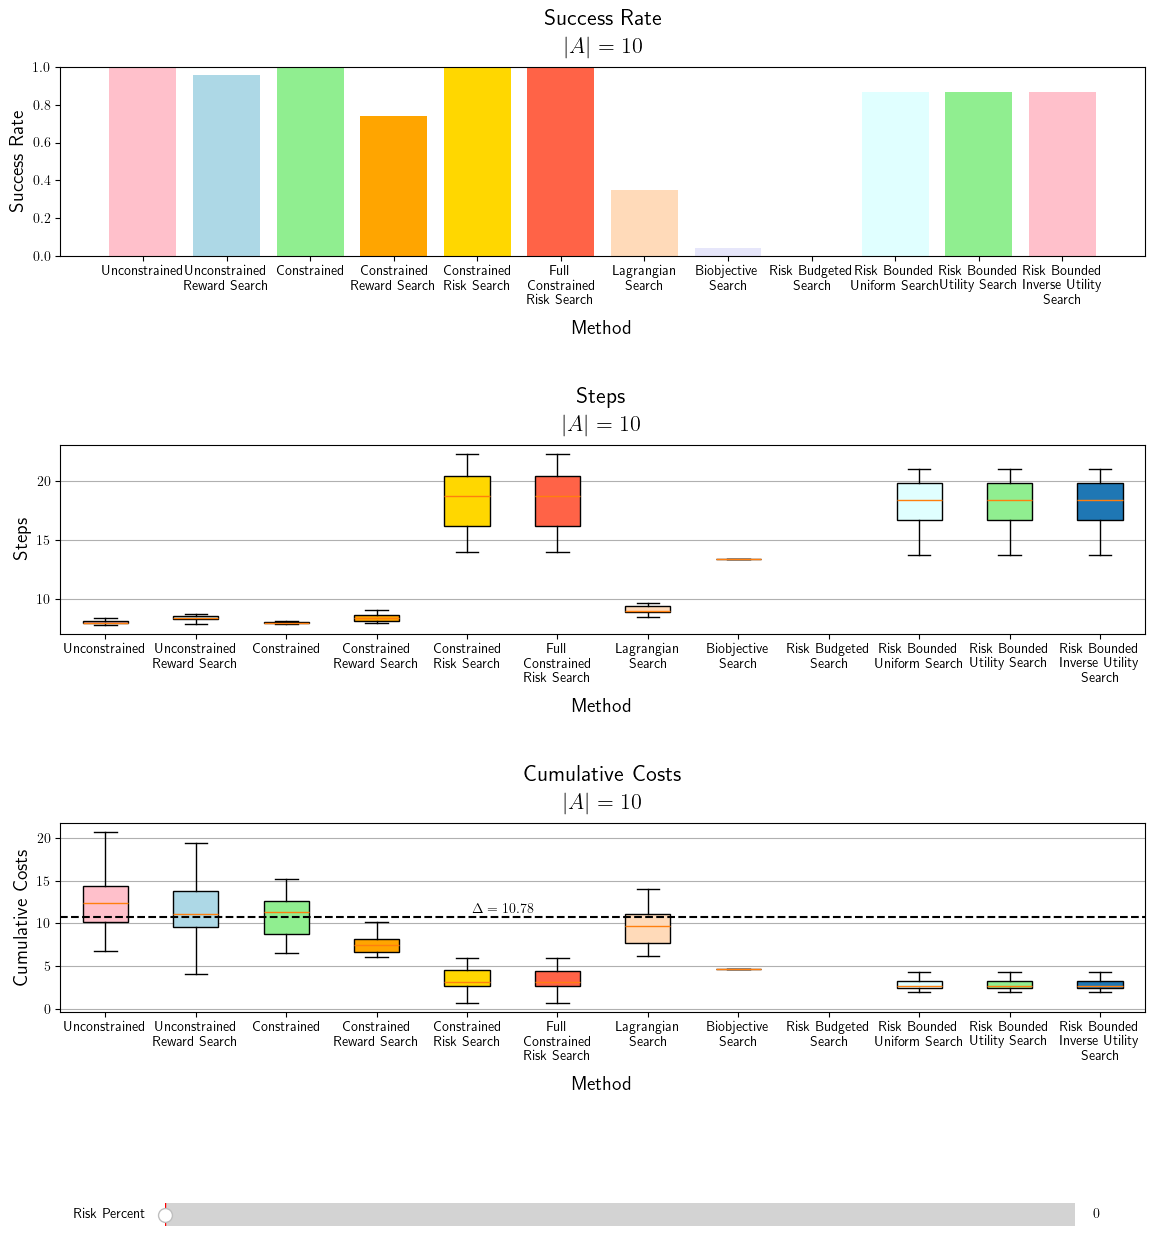

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.widgets import Slider
from IPython.display import display

# --- Parameters and Data Loading ---
MAX_AGENTS = [10]
def create_interactive_figure(n_agents):
    # n_agents = MAX_AGENTS[0]

    multi_agent_basedir = basedir / problem_type

    methods = [
        "unconstrained",
        "unconstrained_reward_search",
        "constrained",
        "constrained_reward_search",
        "constrained_risk_search",
        "full_constrained_risk_search",
        "lagrangian_search",
        "biobjective_search",
    ]
    rb_methods = [
        "risk_budgeted_search",
        "risk_bounded_uniform_search",
        "risk_bounded_utility_search",
        "risk_bounded_inverse_utility_search",
    ]

    # Load the risk-bound data
    cbs_lb_data = np.load(multi_agent_basedir / "cbs_risk_bounds" / f"lb_{n_agents}.npy", allow_pickle=True)
    cbs_ub_data = np.load(multi_agent_basedir / "cbs_risk_bounds" / f"ub_{n_agents}.npy", allow_pickle=True)
    lb_data = np.load(multi_agent_basedir / "risk_bounds" / f"lb_{n_agents}.npy", allow_pickle=True)
    ub_data = np.load(multi_agent_basedir / "risk_bounds" / f"ub_{n_agents}.npy", allow_pickle=True)

    # Determine indices to skip based on invalid bounds.
    skip_indices = []
    for pb_idx in range(len(cbs_lb_data)):
        lb_val = max(lb_data[pb_idx], cbs_lb_data[pb_idx])
        ub_val = min(ub_data[pb_idx], cbs_ub_data[pb_idx])
        if lb_val == -1 or ub_val == -1 or lb_val > ub_val:
            skip_indices.append(pb_idx)

    # Pre-load metrics for unconstrained methods (they are risk-percent independent).
    metrics = {}
    for method in methods:
        method_records = np.load(multi_agent_basedir / f"{method}_records_{n_agents}.npy", allow_pickle=True)
        method_metrics = extract_multi_agent_metrics(method_records, n_agents, skip_indices=skip_indices)
        metrics[method] = method_metrics

    # Pre-load risk-bounded records for each risk percentage for rb_methods.
    # We assume each file returns an array-like structure with length 5, one for each risk percentage (0, 0.25, 0.5, 0.75, 1.0).
    rb_records = {}
    for method in rb_methods:
        records = np.load(multi_agent_basedir / f"{method}_records_{n_agents}.npy", allow_pickle=True)
        rb_records[method] = records

    # --- Plotting with a Slider ---
    fig, ax = plt.subplots(3, 1, figsize=(14, 15))
    plt.subplots_adjust(bottom=0.25, hspace=1.0)  # Make room at the bottom for the slider.

    def update_plot(idx):
        """
        Update the box plot for a given risk percentage index.
        idx: integer from 0 to 4 (risk_percent = idx/4)
        """
        risk_percent = idx / 4.0
        
        # Compute the delta values (upper bounds) for this risk percentage.
        deltas = []
        for pb_idx in range(len(cbs_lb_data)):
            if pb_idx in skip_indices:
                continue
            lb_val = max(lb_data[pb_idx], cbs_lb_data[pb_idx])
            ub_val = min(ub_data[pb_idx], cbs_ub_data[pb_idx])
            delta = lb_val + risk_percent * (ub_val - lb_val)
            deltas.append(delta)
        
        # For each risk-bounded method, extract the metrics corresponding to this risk percentage.
        for method in rb_methods:
            # Here we select the records corresponding to the current risk percent index.
            method_records = rb_records[method][idx]
            method_metrics = extract_multi_agent_metrics(method_records, n_agents, skip_indices=skip_indices)
            metrics[method] = method_metrics

        # Combine metrics from all methods for plotting.
        # We also include the computed delta values as a dictionary with key "mean_cumulative_costs".
        metrics_list = [metrics[method] for method in methods + rb_methods]
        # metrics_list.append({"mean_cumulative_costs": deltas})
        
        # Clear the current axes and replot the box plot.
        for a in ax:
            a.cla()
        # The function plot_everything should be modified (if needed) to plot into the provided axis (ax).
        plot_everything(metrics_list, n_agents, ax=ax, delta=np.mean(deltas))
        fig.canvas.draw_idle()

    # Initialize the plot using risk percentage index 0 (i.e. 0%).
    initial_idx = 0
    update_plot(initial_idx)

    # Create the slider. Its value will be one of the integers 0,1,2,3,4 corresponding to risk percent values 0,0.25,...,1.0.
    slider_ax = plt.axes([0.2, 0.1, 0.65, 0.03])
    slider = Slider(slider_ax, 'Risk Percent', 0.0, 4.0, valinit=0.0, valstep=None)
    slider.last_idx = 0

    def slider_update(val):
        new_idx = int(round(val))
        slider.valtext.set_text(f"{(new_idx/4.0) * 100:.0f}\%")
        if new_idx != slider.last_idx:
            slider.last_idx = new_idx
            update_plot(new_idx)

    slider.on_changed(slider_update)
    update_plot(0)
    return fig

tabs = widgets.Tab()
children = []
for idx, n_agents in enumerate(MAX_AGENTS):
    out = widgets.Output()
    with out:
        display(create_interactive_figure(n_agents).canvas)
        # plt.close(fig)
    children.append(out)
tabs.children = children
for idx, n_agents in enumerate(MAX_AGENTS):
    tabs.set_title(idx, f'{n_agents} Agents')

display(tabs);
